## Diagnostic Analysis


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../Source data/realistic_e_commerce_sales_data.csv")
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


### Check for Missing Values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64



### Correlation Matrix

In [7]:
numeric_cols = ['Age','Unit Price','Quantity','Total Price','Shipping Fee']
corr = df[numeric_cols].corr()
print("Correlation Matrix:")
print(corr)


Correlation Matrix:
                   Age  Unit Price  Quantity  Total Price  Shipping Fee
Age           1.000000    0.056832  0.014651     0.038775      0.027020
Unit Price    0.056832    1.000000  0.002678     0.824360      0.016851
Quantity      0.014651    0.002678  1.000000     0.360877      0.045812
Total Price   0.038775    0.824360  0.360877     1.000000      0.003249
Shipping Fee  0.027020    0.016851  0.045812     0.003249      1.000000


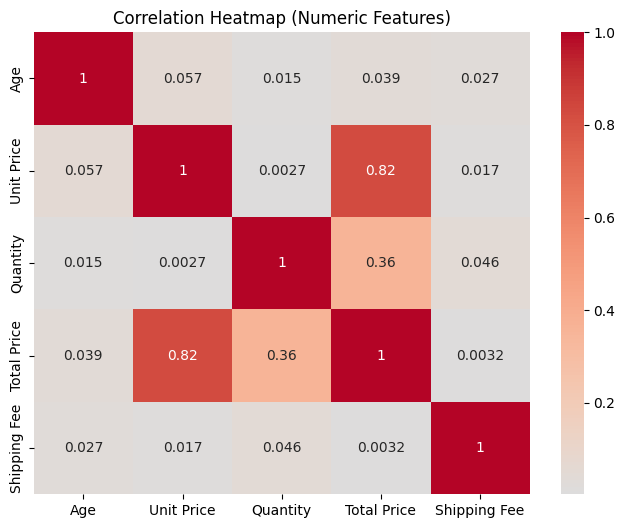

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


### Group Comparisons

In [20]:
#Average by region
region_spend = df.groupby('Region')['Total Price'].mean()
print("Average Spend by Region:")
print(region_spend)
print("\n")
#return by region
returns_by_region = df[df['Shipping Status']=="Returned"].groupby('Region')['Customer ID'].count()
print("Returned Orders by Region:")
print(returns_by_region)


Average Spend by Region:
Region
East     1428.354978
North    1419.170306
South    1233.770492
West     1314.593496
Name: Total Price, dtype: float64


Returned Orders by Region:
Region
East     62
North    65
South    64
West     95
Name: Customer ID, dtype: int64


### Scatterplots for Relationships

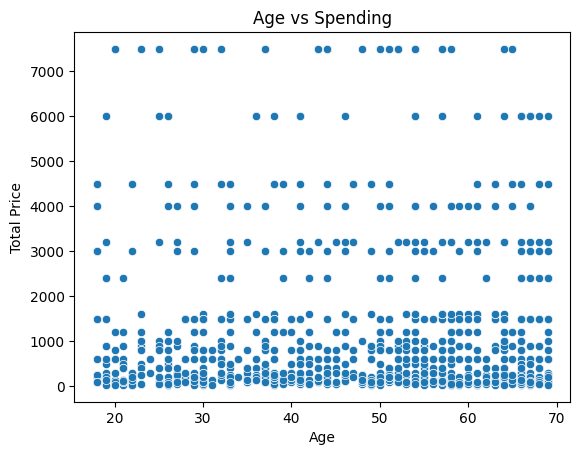

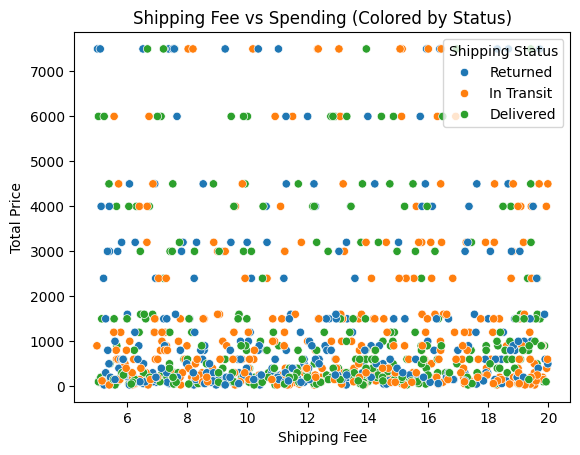

In [12]:
# Age vs Total Price
sns.scatterplot(x='Age', y='Total Price', data=df)
plt.title("Age vs Spending")
plt.show()

# Shipping Fee vs Total Price
sns.scatterplot(x='Shipping Fee', y='Total Price', data=df, hue='Shipping Status')
plt.title("Shipping Fee vs Spending (Colored by Status)")
plt.show()
